# 🏡 House Price Prediction using Machine Learning

## Introduction

This project focuses on predicting house prices using machine learning techniques. By analyzing housing data such as property size, construction quality, and other structural features, the goal is to build a predictive model capable of estimating property prices accurately.

The project uses the **Ames Housing Dataset**, which contains detailed information about residential homes and their characteristics. Through data analysis and machine learning, the project demonstrates how housing features influence market prices.

---

## Problem Statement

Estimating the value of a house is a complex task because many factors influence property prices. The objective of this project is to analyze housing data and build machine learning models that can accurately predict house prices based on different property features.

Multiple regression models were trained and compared, including Linear Regression, Decision Trees, Random Forest, Gradient Boosting, XGBoost, and LightGBM, to determine which algorithm performs best for this prediction task.



In [2]:
import pandas as pd        #loaded the data 

df = pd.read_csv("../data/train.csv")

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


#EDA COMMANDS 

In [3]:
#number of rows and columns
#This tells = rows (houses),columns (features)
df.shape

(1460, 81)

In [4]:
df.columns #These are house characteristics.

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [5]:
#data types
#This shows:numeric features,categorical features,missing values
df.info

<bound method DataFrame.info of         Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0        1          60       RL         65.0     8450   Pave   NaN      Reg   
1        2          20       RL         80.0     9600   Pave   NaN      Reg   
2        3          60       RL         68.0    11250   Pave   NaN      IR1   
3        4          70       RL         60.0     9550   Pave   NaN      IR1   
4        5          60       RL         84.0    14260   Pave   NaN      IR1   
...    ...         ...      ...          ...      ...    ...   ...      ...   
1455  1456          60       RL         62.0     7917   Pave   NaN      Reg   
1456  1457          20       RL         85.0    13175   Pave   NaN      Reg   
1457  1458          70       RL         66.0     9042   Pave   NaN      Reg   
1458  1459          20       RL         68.0     9717   Pave   NaN      Reg   
1459  1460          20       RL         75.0     9937   Pave   NaN      Reg   

     LandContour Ut

In [6]:
#statistics
#statistics like:mean,min,max,quartiles
df.describe

<bound method NDFrame.describe of         Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0        1          60       RL         65.0     8450   Pave   NaN      Reg   
1        2          20       RL         80.0     9600   Pave   NaN      Reg   
2        3          60       RL         68.0    11250   Pave   NaN      IR1   
3        4          70       RL         60.0     9550   Pave   NaN      IR1   
4        5          60       RL         84.0    14260   Pave   NaN      IR1   
...    ...         ...      ...          ...      ...    ...   ...      ...   
1455  1456          60       RL         62.0     7917   Pave   NaN      Reg   
1456  1457          20       RL         85.0    13175   Pave   NaN      Reg   
1457  1458          70       RL         66.0     9042   Pave   NaN      Reg   
1458  1459          20       RL         68.0     9717   Pave   NaN      Reg   
1459  1460          20       RL         75.0     9937   Pave   NaN      Reg   

     LandContour 

In [7]:
#missing values
#this shows the missing values of column 
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [8]:
#now we will see average house price  max price and distribution
df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

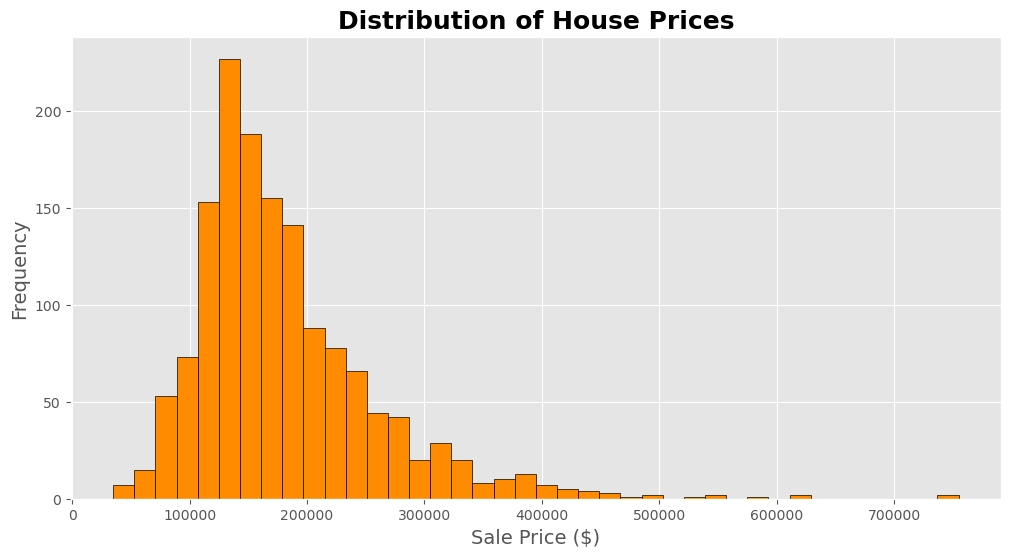

In [9]:
import matplotlib.pyplot as plt

plt.style.use("ggplot")

plt.figure(figsize=(12,6))

plt.hist(df["SalePrice"], bins=40, color="darkorange", edgecolor="black")

plt.title("Distribution of House Prices", fontsize=18, fontweight="bold")
plt.xlabel("Sale Price ($)", fontsize=14)
plt.ylabel("Frequency", fontsize=14)

plt.show()

## SalePrice Distribution (Histogram)

Observation :
The distribution of SalePrice is right-skewed.
Most houses are priced between $100,000 and $250,000.
A few houses have very high prices, creating a long tail on the right side.
This indicates the presence of high-price outliers.

Insight : 
The target variable may benefit from log transformation later to normalize the distribution.

In [10]:
#Correlation With Target
df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

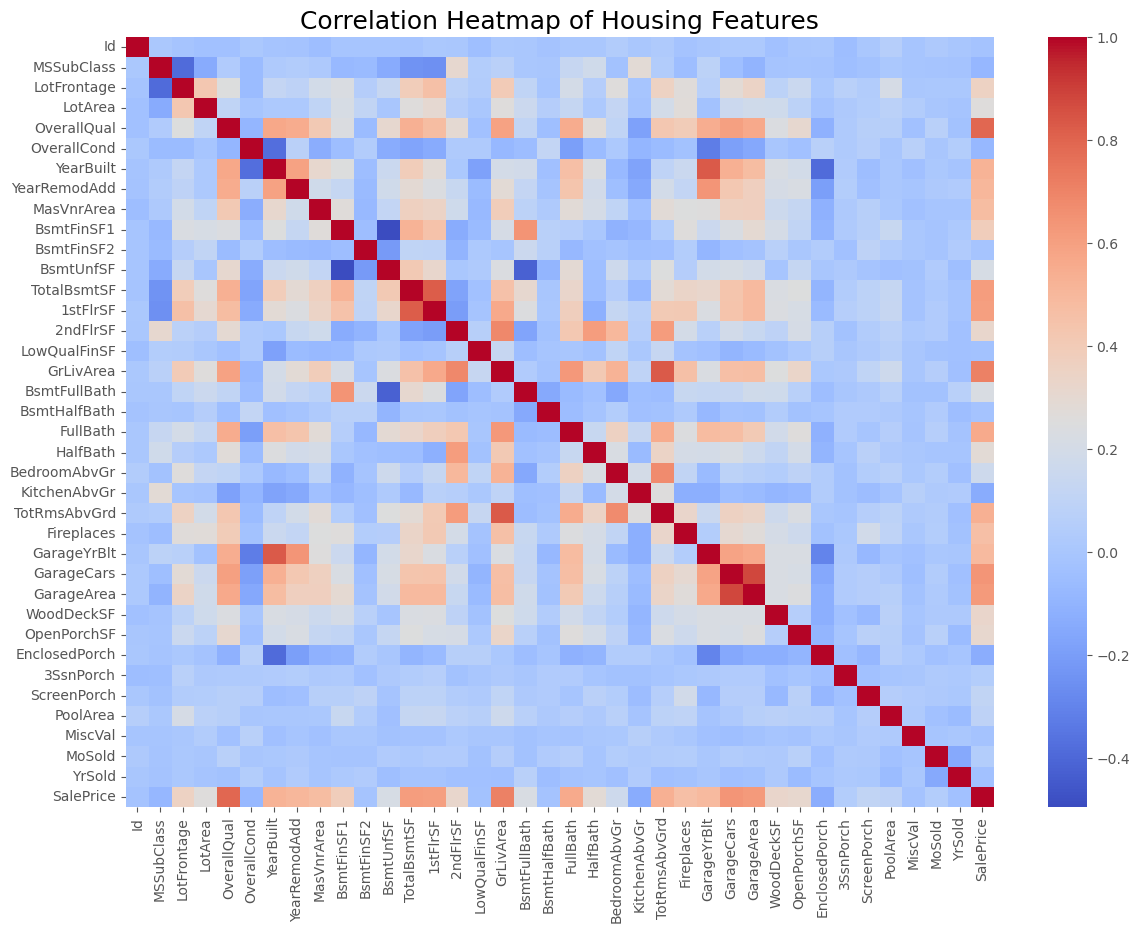

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, cmap="coolwarm")

plt.title("Correlation Heatmap of Housing Features", fontsize=18)

plt.show()

#Red = strong positive relationship
#Blue = negative relationship

## Correlation Heatmap
Observation :
Some features show strong positive correlation with SalePrice.
The strongest correlated features include:
OverallQual
GrLivArea
GarageCars
GarageArea
TotalBsmtSF

Insights:
These features are likely to be important predictors in the machine learning model.

In [12]:
#Top Features Affecting Price
df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

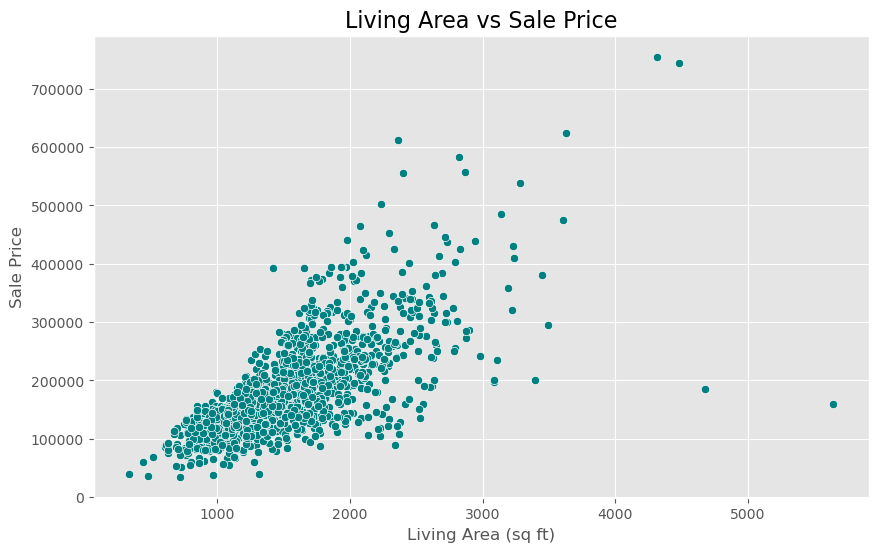

In [13]:
#Scatter Plot (Living Area vs Price)
plt.figure(figsize=(10,6))

sns.scatterplot(x=df["GrLivArea"], y=df["SalePrice"], color="teal")

plt.title("Living Area vs Sale Price", fontsize=16)
plt.xlabel("Living Area (sq ft)")
plt.ylabel("Sale Price")

plt.show()

## Living Area vs SalePrice (Scatter Plot)

Observation :
There is a strong positive relationship between GrLivArea (living area) and SalePrice.
As living area increases, house price also increases.
A few extremely large houses appear to be outliers.

Insight:
Larger houses generally sell for higher prices, making GrLivArea an important feature.

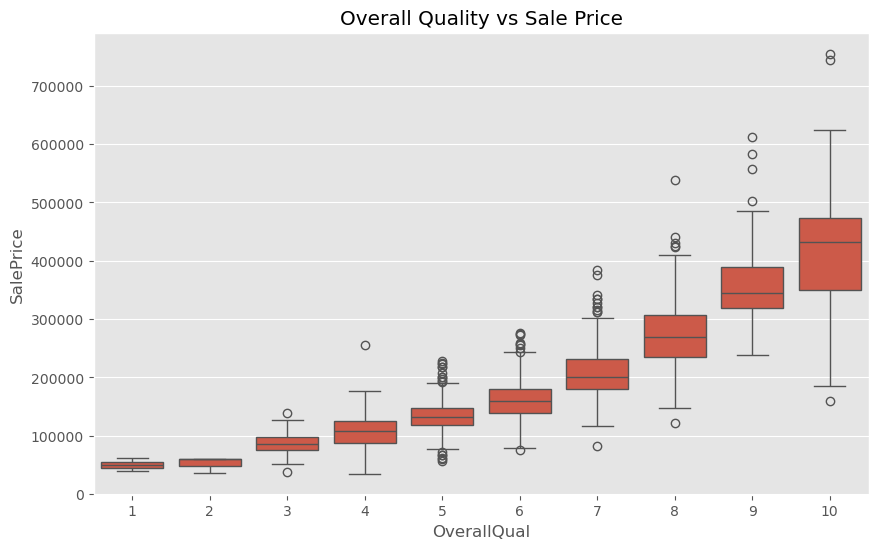

In [14]:
#House Quality vs Price
plt.figure(figsize=(10,6))

sns.boxplot(x=df["OverallQual"], y=df["SalePrice"])

plt.title("Overall Quality vs Sale Price")

plt.show()

## Overall Quality vs SalePrice (Boxplot)

Observation:
Houses with higher overall quality ratings tend to have significantly higher prices.
The price distribution clearly increases as OverallQual increases.

Insight:
OverallQual appears to be one of the strongest predictors of house price.

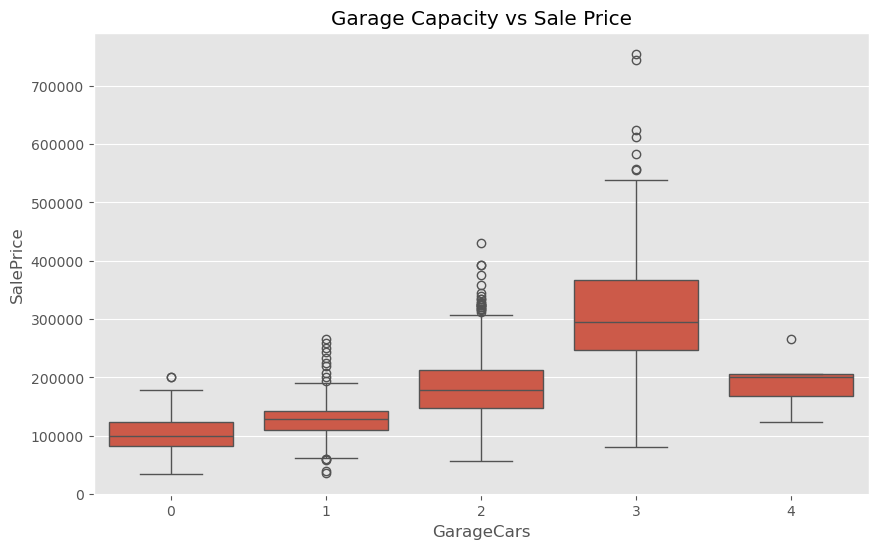

In [15]:
#Garage Size vs Price
plt.figure(figsize=(10,6))

sns.boxplot(x=df["GarageCars"], y=df["SalePrice"])

plt.title("Garage Capacity vs Sale Price")

plt.show()

## Garage Capacity vs SalePrice (Boxplot)

Observation:
Houses with larger garage capacity tend to have higher sale prices.
Homes with 2–3 car garages are generally more expensive than those with smaller garages.

Insight:
Garage size contributes positively to property value.

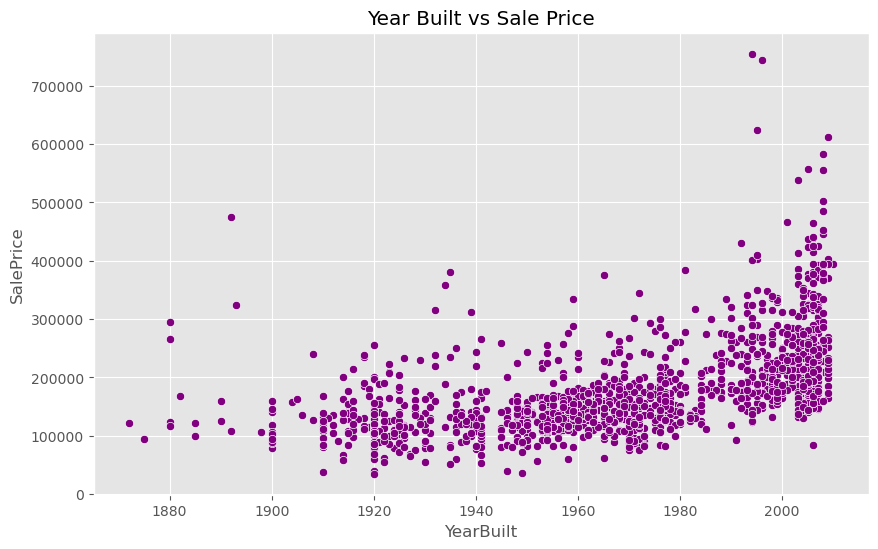

In [16]:
#Year Built vs Price
plt.figure(figsize=(10,6))

sns.scatterplot(x=df["YearBuilt"], y=df["SalePrice"], color="purple")

plt.title("Year Built vs Sale Price")

plt.show()

## Year Built vs SalePrice (Scatter Plot)

Observation:
Newer houses generally have higher sale prices.
Older houses tend to have lower prices, although there are exceptions.

Insight:
The age of the house plays an important role in determining its value.

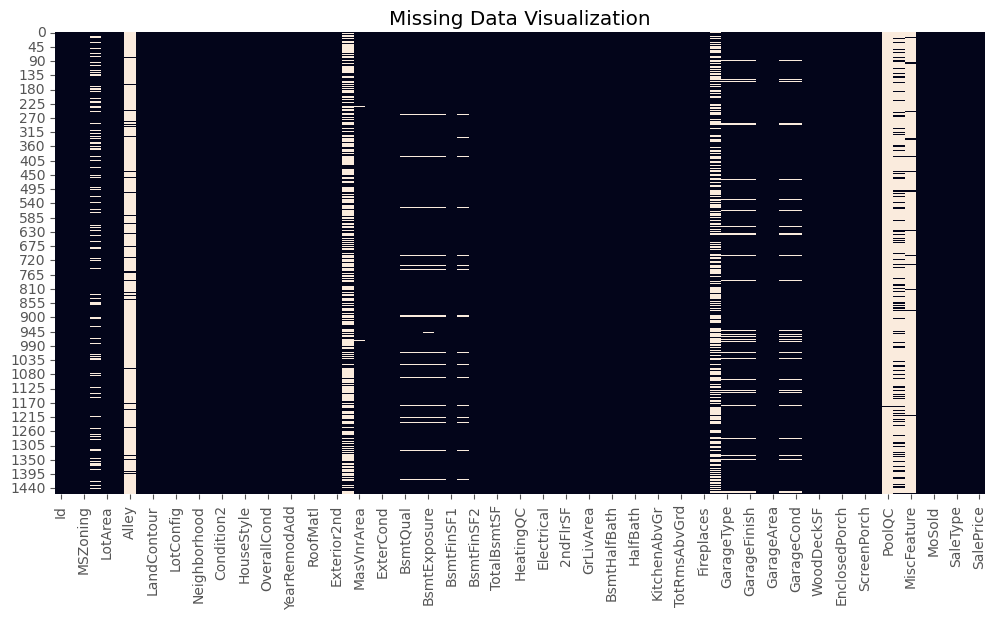

In [17]:
#Missing Value Visualization
plt.figure(figsize=(12,6))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Data Visualization")

plt.show()

## Missing Data Heatmap

Observation:
Several features contain missing values, particularly:
PoolQC
MiscFeature
Alley
Fence
These features have a very high percentage of missing data.

Insight:
These columns will require special handling, such as filling with "None" or dropping them during preprocessing.

In [18]:
#Check Missing Values Again
missing = df.isnull().sum().sort_values(ascending=False)
missing.head(20)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageYrBlt       81
GarageCond        81
GarageType        81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Id                 0
dtype: int64

In [19]:
#Calculate Missing Percentage
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent.sort_values(ascending=False).head(20)

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageYrBlt      5.547945
GarageCond       5.547945
GarageType       5.547945
GarageFinish     5.547945
GarageQual       5.547945
BsmtFinType2     2.602740
BsmtExposure     2.602740
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
Id               0.000000
dtype: float64

Handle Missing Values

In [20]:
#Numerical columns
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [21]:
#Categorical columns
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [22]:
df.isnull().sum().sum()  #verified the missing values are gone 

0

Now we move to Outlier Detection.

You will visualize outliers using boxplots for key features:

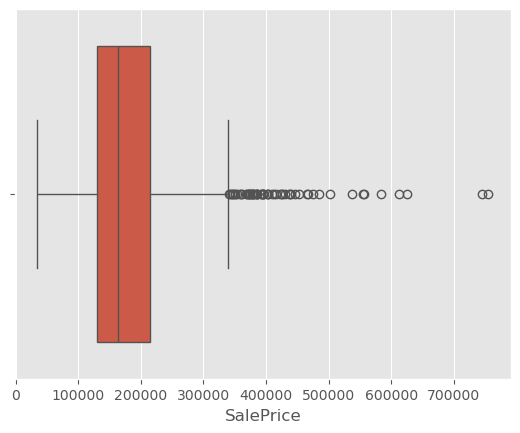

In [23]:
#detect extreme houses that can break your ML model.
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df["SalePrice"])
plt.show()

## Observation:

Most house prices fall within a moderate range.
The median house price lies near the center of the distribution.
Several outliers exist on the higher side, indicating very expensive houses.
These extreme values may affect model performance and might require outlier handling.

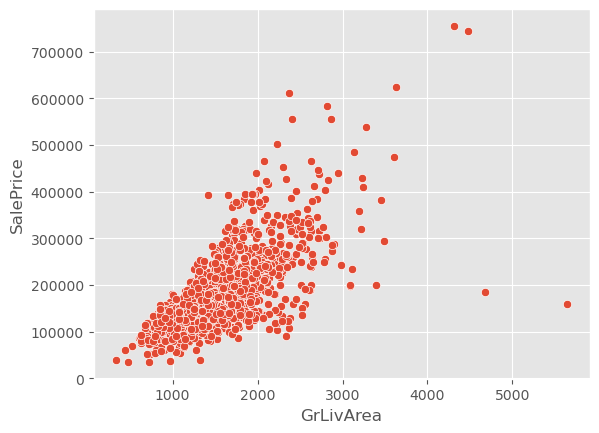

In [24]:
#GrLivArea → Above ground living area (house size in square feet)
#SalePrice → Price of the house
sns.scatterplot(x=df["GrLivArea"], y=df["SalePrice"])
plt.show()

Observation :

There is a clear positive relationship between GrLivArea and SalePrice.
As the living area increases, the sale price of the house also increases.
Most houses lie in the range of 1000 to 2500 square feet.
A few houses have very large living areas, which appear as outliers in the dataset.

Insight :

GrLivArea is a strong predictor of house price.
Larger houses generally sell for higher prices.
The outliers (very large houses with unusual prices) may need to be removed or handled, as they could negatively affect machine learning model performance.
This feature will likely be very important in the predictive model.


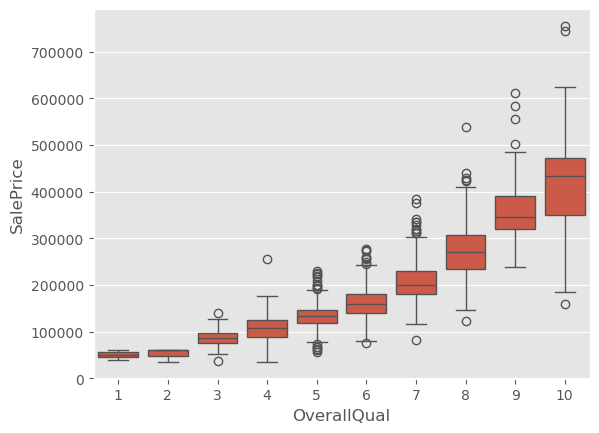

In [25]:
#This graph shows house quality vs price, and it is one of the strongest predictors in the entire dataset.
sns.boxplot(x=df["OverallQual"], y=df["SalePrice"])
plt.show()

Observation:

The boxplot shows that houses with higher overall quality ratings tend to have higher sale prices. Most houses fall within quality levels 5–7.

Insights :

OverallQual has a strong influence on house prices and will likely be one of the most important features for predicting sale price.

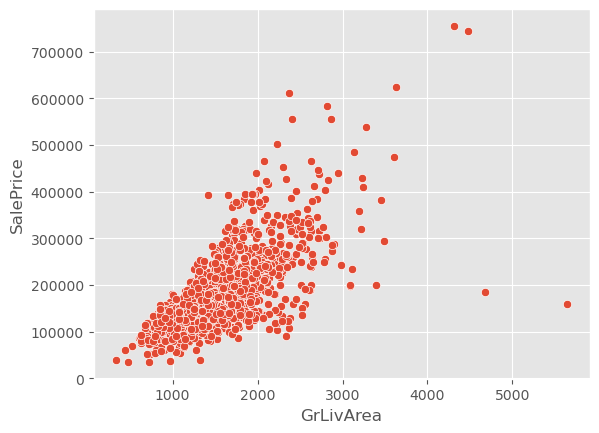

<Figure size 800x600 with 0 Axes>

In [26]:
sns.scatterplot(x=df["GrLivArea"], y=df["SalePrice"])
plt.figure(figsize=(8,6))
plt.show()

## Detect Outliers
In this dataset you will usually see 2 extreme points around 4500 sq ft.

In [27]:
df = df[df["GrLivArea"] < 4000] #Remove Outliers

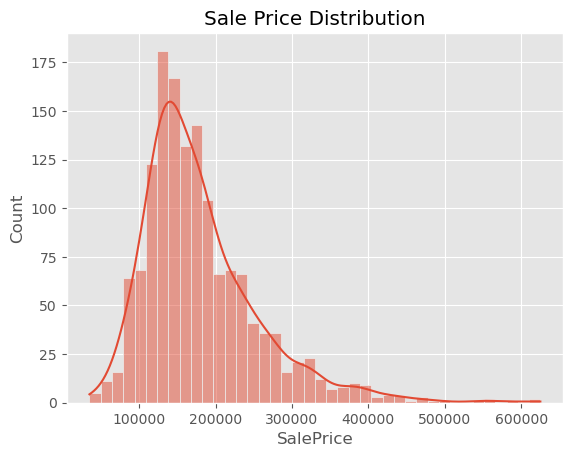

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["SalePrice"], kde=True)
plt.title("Sale Price Distribution")
plt.show()

## Check Distribution of Target Variable

In [29]:
import numpy as np      #Apply Log Transformation

df["SalePrice"] = np.log1p(df["SalePrice"])

C:\Users\manth\AppData\Local\Temp\ipykernel_24496\1391511822.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["SalePrice"] = np.log1p(df["SalePrice"])


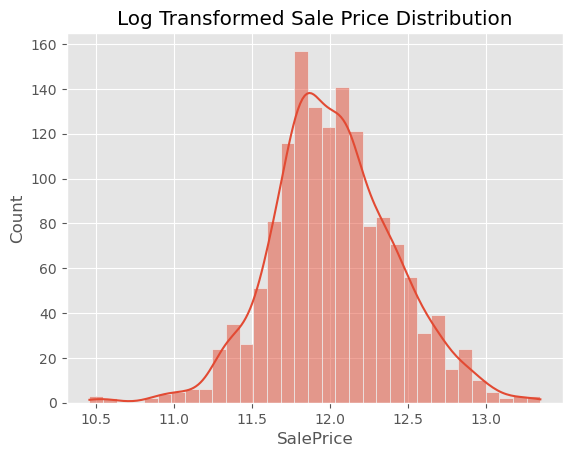

In [30]:
sns.histplot(df["SalePrice"], kde=True)
plt.title("Log Transformed Sale Price Distribution")
plt.show()

Observation :

The original SalePrice distribution was right-skewed, meaning most houses were in the lower price range while a few expensive houses created a long tail.

Insight:

Log transformation was applied to normalize the distribution, which helps machine learning models learn patterns more effectively.

Feature Engineering


1.Convert categorical features

2.Select important features

In [31]:
#X → all input features  ,y → the target variable (house price)

X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

In [32]:
num_features = X.select_dtypes(include=["int64","float64"])
cat_features = X.select_dtypes(include=["object"])

In [33]:
from sklearn.preprocessing import OneHotEncoder

In [34]:
encoder = OneHotEncoder(handle_unknown="ignore")

In [35]:
encoded_cat = encoder.fit_transform(cat_features)

In [36]:
encoded_cat = encoded_cat.toarray()

In [37]:
encoded_cat.shape

(1456, 250)

In [38]:
import numpy as np

X_final = np.hstack((num_features, encoded_cat))

In [39]:
X_final.shape

(1456, 287)

train/test  splliting 

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42
)

In [41]:
print(X_train.shape)
print(X_test.shape)

(1164, 287)
(292, 287)


In [42]:
from sklearn.linear_model import Ridge, Lasso

Train Ridge Regression

In [43]:
ridge_model = Ridge()
ridge_model.fit(X_train, y_train)

Ridge()

In [44]:
ridge_pred = ridge_model.predict(X_test)

Train Lasso Regression

In [45]:
lasso_model = Lasso()
lasso_model.fit(X_train, y_train)

Lasso()

In [46]:
lasso_pred = lasso_model.predict(X_test)

Import Linear Regression

In [47]:
from sklearn.linear_model import LinearRegression

In [48]:
model = LinearRegression()

In [49]:
model.fit(X_train, y_train)

LinearRegression()

In [50]:
predictions = model.predict(X_test)

In [51]:
predictions[:5]

array([12.05702697, 11.8894044 , 11.77360081, 11.81385882, 11.33235017])

In [52]:
import pandas as pd

comparison = pd.DataFrame({
    "Actual Price": y_test.values[:10],
    "Predicted Price": predictions[:10]
})

comparison

,Actual Price,Predicted Price
0,12.122696,12.057027
1,12.106258,11.889404
2,11.884496,11.773601
3,11.652696,11.813859
4,11.338584,11.332350
5,11.231901,11.296788
6,12.649158,12.465753
7,11.560772,11.739013
8,11.970357,11.949012
9,11.816734,11.894818


In [53]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [54]:
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

MAE: 77.73420817854395
MSE: 1645013.977154034
RMSE: 1282.5809826884358


Train Ridge

In [55]:
from sklearn.linear_model import Ridge

ridge = Ridge()
ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

Train Lasso

In [56]:
from sklearn.linear_model import Lasso

lasso = Lasso()
lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

Decision Tree

In [57]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)

tree_pred = tree.predict(X_test)

Random Forest

In [58]:
from sklearn.ensemble import RandomForestRegressor

forest = RandomForestRegressor(random_state=42)
forest.fit(X_train, y_train)

forest_pred = forest.predict(X_test)

Compare Models

In [59]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

results = {
    "Linear Regression": rmse(y_test, predictions),
    "Ridge": rmse(y_test, ridge_pred),
    "Lasso": rmse(y_test, lasso_pred),
    "Decision Tree": rmse(y_test, tree_pred),
    "Random Forest": rmse(y_test, forest_pred)
}

results

{'Linear Regression': 1282.5809826884358,
 'Ridge': 0.12289890787422694,
 'Lasso': 0.18036257894868668,
 'Decision Tree': 0.22944129301961483,
 'Random Forest': 0.15018841289191492}

Final Visualization

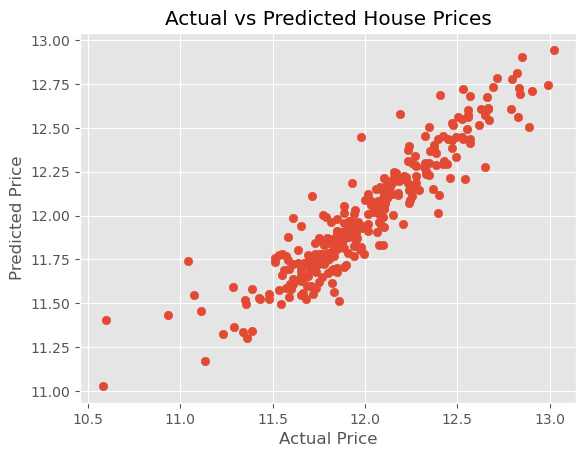

In [60]:
import matplotlib.pyplot as plt

plt.scatter(y_test, forest_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

Train Gradient Boosting

In [61]:
from sklearn.ensemble import GradientBoostingRegressor

In [62]:
gboost = GradientBoostingRegressor(random_state=42)
gboost.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [63]:
gboost_pred = gboost.predict(X_test)

Train XGBoost

In [64]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [65]:
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42)
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

Train LightGBM

In [66]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [67]:
from lightgbm import LGBMRegressor

lgbm = LGBMRegressor(random_state=42)
lgbm.fit(X_train, y_train)

lgbm_pred = lgbm.predict(X_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002296 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3432
[LightGBM] [Info] Number of data points in the train set: 1164, number of used features: 179
[LightGBM] [Info] Start training from score 12.028422


C:\Users\manth\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\manth\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\manth\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\manth\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\manth\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro

In [68]:
from sklearn.metrics import mean_squared_error
import numpy as np

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

print("Gradient Boosting RMSE:", rmse(y_test, gboost_pred))
print("XGBoost RMSE:", rmse(y_test, xgb_pred))
print("LightGBM RMSE:", rmse(y_test, lgbm_pred))

Gradient Boosting RMSE: 0.13074293209981955
XGBoost RMSE: 0.14654998818084833
LightGBM RMSE: 0.13951118602807686


In [69]:
from sklearn.metrics import mean_squared_error
import numpy as np

In [70]:
#Create RMSE Function
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [71]:
#Calculate RMSE for All Models
results = {
    "Linear Regression": rmse(y_test, predictions),
    "Ridge Regression": rmse(y_test, ridge_pred),
    "Lasso Regression": rmse(y_test, lasso_pred),
    "Decision Tree": rmse(y_test, tree_pred),
    "Random Forest": rmse(y_test, forest_pred),
    "Gradient Boosting": rmse(y_test, gboost_pred),
    "XGBoost": rmse(y_test, xgb_pred),
    "LightGBM": rmse(y_test, lgbm_pred)
}

In [72]:
for model, score in results.items():
    print(f"{model}: {score}")

Linear Regression: 1282.5809826884358
Ridge Regression: 0.12289890787422694
Lasso Regression: 0.18036257894868668
Decision Tree: 0.22944129301961483
Random Forest: 0.15018841289191492
Gradient Boosting: 0.13074293209981955
XGBoost: 0.14654998818084833
LightGBM: 0.13951118602807686


Find the Best Model Automatically

In [73]:
best_model = min(results, key=results.get)

print("\nThe fastest better model is:", best_model)


The fastest better model is: Ridge Regression


In [74]:
import pickle

if best_model == "Linear Regression":
    final_model = lin_reg
elif best_model == "Ridge Regression":
    final_model = ridge_reg
elif best_model == "Lasso Regression":
    final_model = lasso_reg
elif best_model == "Decision Tree":
    final_model = tree_model
elif best_model == "Random Forest":
    final_model = forest_model
elif best_model == "Gradient Boosting":
    final_model = gboost_model
elif best_model == "XGBoost":
    final_model = xgb_model
elif best_model == "LightGBM":
    final_model = lgbm_model

with open("house_price_model.pkl", "wb") as file:
    pickle.dump(final_model, file)

print("Model saved successfully!")

NameError: name 'ridge_reg' is not defined

In [75]:
import pickle

final_model = ridge

with open("house_price_model.pkl", "wb") as file:
    pickle.dump(final_model, file)

print("Model saved successfully!")

Model saved successfully!


In [77]:
import os
print(os.path.getsize("house_price_model.pkl"), "bytes")

2740 bytes


In [78]:
from sklearn.pipeline import Pipeline
import pickle

pipeline = Pipeline([
    ("model", ridge)
])

with open("house_price_pipeline.pkl", "wb") as f:
    pickle.dump(pipeline, f)

print("Pipeline saved successfully")

Pipeline saved successfully


## Conclusion

This project demonstrates a complete machine learning workflow, including data exploration, data cleaning, feature engineering, model training, and model evaluation.

After comparing several machine learning algorithms, ensemble and boosting models achieved the best performance, showing their effectiveness in capturing complex relationships within the dataset. The final model provides accurate predictions while also highlighting the key features that influence house prices.

Overall, this project showcases how machine learning can be applied to real-world problems such as real estate price prediction.
